In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

**Preprocessing**

In [7]:
file=pd.read_csv("data_with_weather.csv")

file['datetime']=pd.to_datetime(file['datetime'])

file['hour']=file['datetime'].dt.hour+file['datetime'].dt.minute/60

file=file.sort_values('datetime').reset_index(drop=True)

**Finding good features**

In [8]:

file['demandH1']=file['demand'].shift(1).fillna(0)
file['demandH2']=file['demand'].shift(2).fillna(0)
file['demandH3']=file['demand'].shift(3).fillna(0)
file['demand24H']=file['demand'].shift(24).fillna(0)
file['demand48H']=file['demand'].shift(48).fillna(0)
file['demand168H']=file['demand'].shift(168).fillna(0)
file['roll_mean_24h']=file['demand'].shift(1).rolling(24).mean().fillna(0)

file['hour_sin']=np.sin(2*np.pi*file['hour']/24)
file['hour_cos']=np.cos(2*np.pi*file['hour']/24)

file['minutes']=file['datetime'].dt.hour*60+file['datetime'].dt.minute
file['hour^2']=file['minutes']**2
file['hour^3']=file['minutes']**3

file['demand24HAgo']=file['demand'].shift(24).fillna(0)
file['demand7HAgo']=file['demand'].shift(24*7).fillna(0)

hourOneHotEncoding=pd.get_dummies(file['hour'],prefix='h').astype(int)
file=pd.concat([file,hourOneHotEncoding],axis=1)
hour_columns=[col for col in file.columns if col.startswith('h_')]

for h in hour_columns:
    file[f'{h}_weekend']=file[h]*file['is_weekend']

file['rush']=( (file['hour'] == 7) & (file['is_weekend'] == 0)).astype(int)
cols=[col for col in file.columns if col.endswith('_weekend')]
# print(file.head()) # print the beginning of the file
# print(file.info()) # Print name of columns
weather_columns=['temp','feelslike', 'precip','snow','snowdepth','is_snowing','is_raining']

features=['minutes','is_weekend','event','rush','demandH1','demandH2','demandH3','hour_sin','hour_cos','demand24HAgo','demand7HAgo']+cols+hour_columns+weather_columns
file['rain_rush']=file['is_raining']* file['rush']
features.append('rain_rush')

**Dividing test and train data**

In [9]:
split_idx=int(len(file)*0.80)
trf=file.iloc[:split_idx]
tef=file.iloc[split_idx:]

x_train=trf[features]
x_test=tef[features]
y_train=trf['demand']
y_test=tef['demand']
model=LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

**Running the model and metrics**

In [10]:

pred=model.predict(x_test)
y_pred=np.maximum(0,pred)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
mae=mean_absolute_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)

print()
print(f"RMSE : {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")
print(f"R^2 : {r2:.4f}")


RMSE : 7,830.85
MAE : 4,739.80
R^2 : 0.8806


**Graph of metrics**

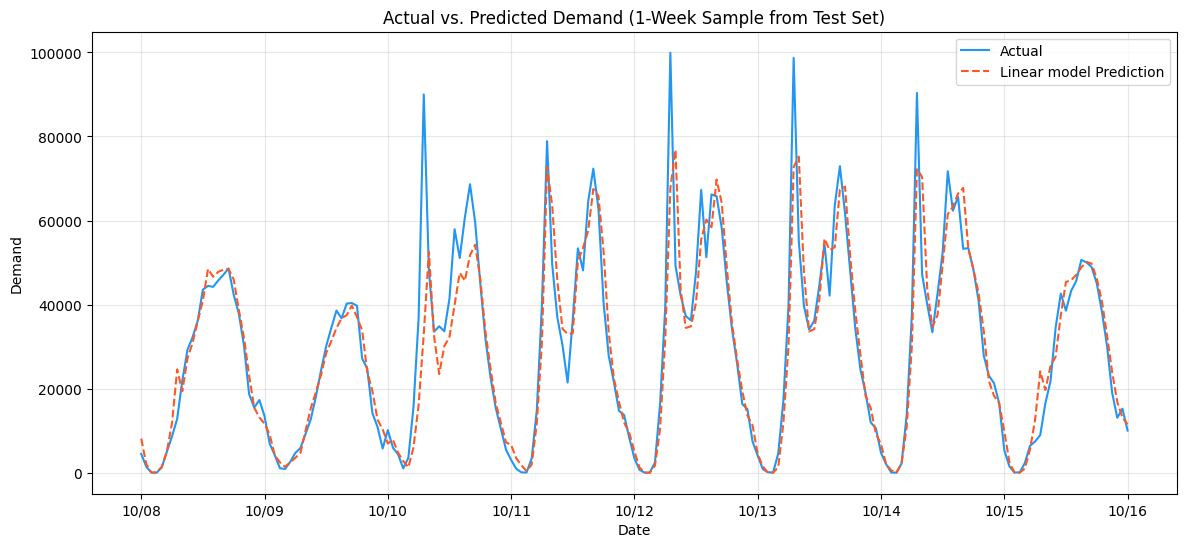

In [11]:

mask=(tef['datetime']>='2022-10-08') & (tef['datetime']<='2022-10-16')
tef_periode=tef.loc[mask]
y_test_periode=y_test.loc[mask]
y_pred_periode=y_pred[mask.values]
plt.figure(figsize=(14,6))

plt.plot(tef_periode['datetime'],y_test_periode, label="Actual",color="#2196F3",linewidth=1.5)
plt.plot(tef_periode['datetime'], y_pred_periode,label="Linear model Prediction",color="#FF5722",linestyle="--",linewidth=1.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.title("Actual vs. Predicted Demand (1-Week Sample from Test Set)")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()